In [ ]:
print("test")

StatementMeta(smallsparkpool, 7, 5, Finished, Available, Finished, False)

test


In [ ]:
# ─────────────────────────────────────────────
# CELL 1 — Imports and config
# Shows: Setting up spark environment
# ─────────────────────────────────────────────

#import the spark session
from pyspark.sql import SparkSession

#importing the spark dataframe and sql features
from pyspark.sql.functions import (
    col, when, trim, upper, initcap,
    count, avg, min, max, round as spark_round,
    udf, lit, current_timestamp
)
from pyspark.sql.types import IntegerType, StringType
from pyspark.sql.window import Window
import pyspark.sql.functions as F

# Paths -- centralise them here so easy to change
#making the filepath variable , easy to understand and access

STORAGE   = "YOUR_STORAGE_ACCOUNT_NAME" #storage manager replace this with your storage account name
CONTAINER = "raw-data" #the container where my csv lives

#abfss://{raw-data}@{medicalwarehousedl}.dfs.core.windows.net
BASE_PATH = f"abfss://{CONTAINER}@{STORAGE}.dfs.core.windows.net"
BRONZE    = f"{BASE_PATH}/bronze/patients/train_data.csv"
SILVER    = f"{BASE_PATH}/silver/patients/"
GOLD      = f"{BASE_PATH}/gold/patient_stats/"

print("Libraries imported successfully")
print(f"Spark version: {spark.version}")
print(f"Bronze path:   {BRONZE}")  #where unprocessed data lives

In [ ]:
# ─────────────────────────────────────────────
# CELL 2 — Load raw data
# Reading my csv files
# ─────────────────────────────────────────────


#.cvs (BRONZE) is the file location to read for spark , it is defined on top
df_raw = (spark.read.option("header", True).option("inferSchema",True).option("nullValue","").csv(BRONZE))

print(f"Raw rows:    {df_raw.count()}")
print(f"Raw columns: {len(df_raw.columns)}")
print("\nSchema:")
df_raw.printSchema()

StatementMeta(smallsparkpool, 7, 7, Finished, Available, Finished, False)

Raw rows:    318438
Raw columns: 18

Schema:
root
 |-- case_id: integer (nullable = true)
 |-- Hospital_code: integer (nullable = true)
 |-- Hospital_type_code: string (nullable = true)
 |-- City_Code_Hospital: integer (nullable = true)
 |-- Hospital_region_code: string (nullable = true)
 |-- Available Extra Rooms in Hospital: integer (nullable = true)
 |-- Department: string (nullable = true)
 |-- Ward_Type: string (nullable = true)
 |-- Ward_Facility_Code: string (nullable = true)
 |-- Bed Grade: integer (nullable = true)
 |-- patientid: integer (nullable = true)
 |-- City_Code_Patient: integer (nullable = true)
 |-- Type of Admission: string (nullable = true)
 |-- Severity of Illness: string (nullable = true)
 |-- Visitors with Patient: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Admission_Deposit: integer (nullable = true)
 |-- Stay: string (nullable = true)



In [ ]:
# ─────────────────────────────────────────────
# CELL 3 — Data profiling BEFORE cleaning
#
# ─────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — BRONZE LAYER")
print("=" * 50)

# 1. Null counts
print("\n--- NULL COUNTS ---")

df_raw.select([count(when(col(c).isNull(), c)).alias(c)for c in df_raw.columns]).show()

# 2. Duplicate check
total      = df_raw.count()
unique     = df_raw.dropDuplicates(["case_id"]).count()
duplicates = total - unique
print(f"--- DUPLICATES ---")
print(f"Total rows:      {total:,}")
print(f"Unique case_ids: {unique:,}")
print(f"Duplicates:      {duplicates:,}")

# 3. Distinct values in categorical columns
print("\n--- DISTINCT VALUES ---")
for col_name in ["Severity of Illness", "Type of Admission",
                 "Stay", "Department"]:
    distinct = df_raw.select(col_name).distinct().count()
    print(f"{col_name}: {distinct} distinct values")

StatementMeta(smallsparkpool, 7, 8, Finished, Available, Finished, False)

DATA QUALITY REPORT — BRONZE LAYER

--- NULL COUNTS ---
+-------+-------------+------------------+------------------+--------------------+---------------------------------+----------+---------+------------------+---------+---------+-----------------+-----------------+-------------------+---------------------+---+-----------------+----+
|case_id|Hospital_code|Hospital_type_code|City_Code_Hospital|Hospital_region_code|Available Extra Rooms in Hospital|Department|Ward_Type|Ward_Facility_Code|Bed Grade|patientid|City_Code_Patient|Type of Admission|Severity of Illness|Visitors with Patient|Age|Admission_Deposit|Stay|
+-------+-------------+------------------+------------------+--------------------+---------------------------------+----------+---------+------------------+---------+---------+-----------------+-----------------+-------------------+---------------------+---+-----------------+----+
|      0|            0|                 0|                 0|                   0|                

In [ ]:
# ─────────────────────────────────────────────
# CELL 4 — Rename columns (fix spaces)
# Shows: DataFrame transformation chaining
# ─────────────────────────────────────────────


# the slash \ means this code continues on the next line" — it's a Python line continuation character.
#You could write the whole thing on one line but it would be very hard to read

df = df_raw \
    .withColumnRenamed("Available Extra Rooms in Hospital",
                       "Available_Extra_Rooms") \
    .withColumnRenamed("Bed Grade",             "Bed_Grade") \
    .withColumnRenamed("Type of Admission",     "Type_of_Admission") \
    .withColumnRenamed("Severity of Illness",   "Severity_of_Illness") \
    .withColumnRenamed("Visitors with Patient", "Visitors_with_Patient")

print("Columns after rename:")
print(df.columns)


StatementMeta(smallsparkpool, 7, 9, Finished, Available, Finished, False)

Columns after rename:
['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital', 'Hospital_region_code', 'Available_Extra_Rooms', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade', 'patientid', 'City_Code_Patient', 'Type_of_Admission', 'Severity_of_Illness', 'Visitors_with_Patient', 'Age', 'Admission_Deposit', 'Stay']


In [ ]:
df.show(5)

StatementMeta(smallsparkpool, 7, 10, Finished, Available, Finished, False)

+-------+-------------+------------------+------------------+--------------------+---------------------+------------+---------+------------------+---------+---------+-----------------+-----------------+-------------------+---------------------+-----+-----------------+-----+
|case_id|Hospital_code|Hospital_type_code|City_Code_Hospital|Hospital_region_code|Available_Extra_Rooms|  Department|Ward_Type|Ward_Facility_Code|Bed_Grade|patientid|City_Code_Patient|Type_of_Admission|Severity_of_Illness|Visitors_with_Patient|  Age|Admission_Deposit| Stay|
+-------+-------------+------------------+------------------+--------------------+---------------------+------------+---------+------------------+---------+---------+-----------------+-----------------+-------------------+---------------------+-----+-----------------+-----+
|      1|            8|                 c|                 3|                   Z|                    3|radiotherapy|        R|                 F|        2|    31397|         

In [ ]:
# ─────────────────────────────────────────────
# CELL 5 — Fix Stay column (Excel corruption)
# Shows: custom UDF, business logic, data fixing
# ─────────────────────────────────────────────

def fix_range_to_midpoint(value):
    """
    Converts range strings to numeric midpoints.
    Also fixes Excel date corruption e.g. 20-Nov → 11-20.

    Examples:
        '0-10'             → 5
        '20-Nov'           → 15  (was 11-20, corrupted by Excel)
        'More than 100 Days' → 110
    """
    if value is None:
        return None

    value = str(value).strip()

    # Fix Excel-corrupted date values
    excel_fixes = {
        "20-Nov": "11-20",
        "Nov-20": "11-20",
        "19-Oct": "10-19",
        "Oct-19": "10-19",
    }
    if value in excel_fixes:
        value = excel_fixes[value]

    # Handle 100+ case
    if "More than 100" in value or "100+" in value:
        return 110

    # Convert range to midpoint
    if "-" in value:
        parts = value.split("-")
        try:
            return (int(parts[0].strip()) +
                    int(parts[1].strip())) // 2
        except:
            return None
    return None

def fix_range_to_text(value):
    """Fixes Excel corruption but keeps as text range"""
    if value is None:
        return "Unknown"
    value = str(value).strip()
    excel_fixes = {"20-Nov": "11-20", "Nov-20": "11-20"}
    return excel_fixes.get(value, value)

#User Defined Function
# Register UDFs
midpoint_udf  = udf(fix_range_to_midpoint, IntegerType())
range_text_udf = udf(fix_range_to_text,    StringType())

# Apply to Stay
df = df \
    .withColumn("Stay_Clean",   range_text_udf(col("Stay"))) \
    .withColumn("Stay_Numeric", midpoint_udf(col("Stay")))

# Apply to Age
df = df \
    .withColumn("Age_Numeric",  midpoint_udf(col("Age")))

# Verify
print("Stay fix verification:")
df.groupBy("Stay", "Stay_Clean", "Stay_Numeric") \
  .count() \
  .orderBy("Stay_Numeric") \
  .show(15)

StatementMeta(smallsparkpool, 7, 11, Finished, Available, Finished, False)

Stay fix verification:
+------------------+------------------+------------+-----+
|              Stay|        Stay_Clean|Stay_Numeric|count|
+------------------+------------------+------------+-----+
|              0-10|              0-10|           5|23604|
|            20-Nov|             11-20|          15|78139|
|             21-30|             21-30|          25|87491|
|             31-40|             31-40|          35|55159|
|             41-50|             41-50|          45|11743|
|             51-60|             51-60|          55|35018|
|             61-70|             61-70|          65| 2744|
|             71-80|             71-80|          75|10254|
|             81-90|             81-90|          85| 4838|
|            91-100|            91-100|          95| 2765|
|More than 100 Days|More than 100 Days|         110| 6683|
+------------------+------------------+------------+-----+



In [ ]:
# ─────────────────────────────────────────────
# CELL 6 — Core cleaning transformations
# Shows: chained withColumn, when/otherwise,
#        fillna, filter, dropDuplicates
# ─────────────────────────────────────────────

df_clean = df \
    .dropDuplicates(["case_id"]) \
    .dropna(subset=["case_id", "patientid", "Hospital_code"]) \
    .filter(col("Admission_Deposit")    >= 0) \
    .filter(col("Visitors_with_Patient") >= 0) \
    .fillna({
        "Bed_Grade":          2.0,
        "City_Code_Patient":  0,
        "Department":         "Unknown"
    }) \
    .withColumn("Hospital_type_code",
        upper(trim(col("Hospital_type_code")))) \
    .withColumn("Hospital_region_code",
        upper(trim(col("Hospital_region_code")))) \
    .withColumn("Ward_Type",
        upper(trim(col("Ward_Type")))) \
    .withColumn("Department",
        initcap(trim(col("Department")))) \
    .withColumn("Type_of_Admission",
        initcap(trim(col("Type_of_Admission")))) \
    .withColumn("Severity_of_Illness",
        initcap(trim(col("Severity_of_Illness"))))

print(f"Rows after cleaning: {df_clean.count():,}")

StatementMeta(smallsparkpool, 7, 12, Finished, Available, Finished, False)

Rows after cleaning: 318,438


In [ ]:
# ─────────────────────────────────────────────
# CELL 7 — Feature engineering
# Shows: business logic, derived columns,
#        adding value beyond raw data
# ─────────────────────────────────────────────

df_clean = df_clean \
    .withColumn("Age_Group",
        when(col("Age_Numeric") <  18, "Child")
        .when(col("Age_Numeric") < 40, "Young Adult")
        .when(col("Age_Numeric") < 65, "Adult")
        .otherwise("Senior")
    ) \
    .withColumn("Stay_Category",
        when(col("Stay_Numeric") <= 20, "Short (0-20 days)")
        .when(col("Stay_Numeric") <= 50, "Medium (21-50 days)")
        .otherwise("Long (50+ days)")
    ) \
    .withColumn("Is_Emergency",
        when(col("Type_of_Admission") == "Emergency",
             lit(1)).otherwise(lit(0))
    ) \
    .withColumn("Is_High_Severity",
        when(col("Severity_of_Illness") == "Extreme",
             lit(1)).otherwise(lit(0))
    ) \
    .withColumn("ingestion_timestamp", current_timestamp())

print("New columns added:")
df_clean.select(
    "Age", "Age_Numeric", "Age_Group",
    "Stay", "Stay_Numeric", "Stay_Category",
    "Is_Emergency", "Is_High_Severity"
).show(5)

StatementMeta(smallsparkpool, 7, 13, Finished, Available, Finished, False)

New columns added:
+-----+-----------+-----------+------+------------+-------------------+------------+----------------+
|  Age|Age_Numeric|  Age_Group|  Stay|Stay_Numeric|      Stay_Category|Is_Emergency|Is_High_Severity|
+-----+-----------+-----------+------+------------+-------------------+------------+----------------+
|31-40|         35|Young Adult|20-Nov|          15|  Short (0-20 days)|           1|               0|
|31-40|         35|Young Adult|20-Nov|          15|  Short (0-20 days)|           0|               0|
|31-40|         35|Young Adult| 21-30|          25|Medium (21-50 days)|           0|               0|
|31-40|         35|Young Adult| 51-60|          55|    Long (50+ days)|           0|               0|
|31-40|         35|Young Adult|20-Nov|          15|  Short (0-20 days)|           1|               0|
+-----+-----------+-----------+------+------------+-------------------+------------+----------------+
only showing top 5 rows



In [ ]:
# ─────────────────────────────────────────────
# CELL 8 — Spark SQL analysis
# use SQL inside Spark
#
# ─────────────────────────────────────────────

# Register clean DataFrame as a SQL temp view
df_clean.createOrReplaceTempView("patients")

print("Temp view 'patients' registered")
print("You can now run SQL directly on your Spark DataFrame")

# Query 1 — Department performance
dept_analysis = spark.sql("""
    SELECT
        Department,
        COUNT(*)                         AS total_patients,
        COUNT(DISTINCT patientid)        AS unique_patients,
        ROUND(AVG(Stay_Numeric),    1)   AS avg_stay_days,
        ROUND(AVG(Admission_Deposit), 2) AS avg_deposit,
        SUM(Is_Emergency)                AS emergency_cases,
        SUM(Is_High_Severity)            AS extreme_cases
    FROM patients
    GROUP BY Department
    ORDER BY total_patients DESC
""")

print("\n--- Department Analysis ---")
dept_analysis.show()

StatementMeta(smallsparkpool, 7, 14, Finished, Available, Finished, False)

Temp view 'patients' registered
You can now run SQL directly on your Spark DataFrame

--- Department Analysis ---
+------------------+--------------+---------------+-------------+-----------+---------------+-------------+
|        Department|total_patients|unique_patients|avg_stay_days|avg_deposit|emergency_cases|extreme_cases|
+------------------+--------------+---------------+-------------+-----------+---------------+-------------+
|        Gynecology|        249486|          83951|         32.2|    4814.57|          95710|        43478|
|        Anesthesia|         29649|          18204|         30.1|    5297.12|           5692|         5453|
|      Radiotherapy|         28516|          14524|         33.3|    4935.69|          11967|         5550|
|Tb & Chest Disease|          9586|           6610|         30.9|    5144.29|           3150|         1802|
|           Surgery|          1201|            572|         37.6|    4941.57|           1157|          440|
+------------------+--

In [ ]:
# ─────────────────────────────────────────────
# CELL 9 — More Spark SQL — advanced queries
#
# ─────────────────────────────────────────────

# Query 2 — Severity vs Stay analysis
severity_stay = spark.sql("""
    SELECT
        Severity_of_Illness,
        Stay_Category,
        COUNT(*)                         AS total_patients,
        ROUND(AVG(Admission_Deposit), 2) AS avg_deposit,
        ROUND(AVG(Stay_Numeric), 1)      AS avg_stay_days
    FROM patients
    GROUP BY Severity_of_Illness, Stay_Category
    ORDER BY Severity_of_Illness, total_patients DESC
""")

print("--- Severity vs Stay ---")
severity_stay.show()

# Query 3 — Window function -- rank departments by patient volume
# within each region (advanced -- shows senior-level SQL skill)
region_rank = spark.sql("""
    SELECT
        Hospital_region_code,
        Department,
        total_patients,
        RANK() OVER (
            PARTITION BY Hospital_region_code
            ORDER BY total_patients DESC
        ) AS rank_in_region
    FROM (
        SELECT
            Hospital_region_code,
            Department,
            COUNT(*) AS total_patients
        FROM patients
        GROUP BY Hospital_region_code, Department
    ) AS dept_counts
    ORDER BY Hospital_region_code, rank_in_region
""")

print("--- Department Rank per Region ---")
region_rank.show(20)

StatementMeta(smallsparkpool, 7, 15, Finished, Available, Finished, False)

--- Severity vs Stay ---
+-------------------+-------------------+--------------+-----------+-------------+
|Severity_of_Illness|      Stay_Category|total_patients|avg_deposit|avg_stay_days|
+-------------------+-------------------+--------------+-----------+-------------+
|            Extreme|Medium (21-50 days)|         27939|    4837.38|         30.3|
|            Extreme|    Long (50+ days)|         14867|     4605.9|         70.5|
|            Extreme|  Short (0-20 days)|         13917|     4719.1|         12.6|
|              Minor|Medium (21-50 days)|         38982|    5062.43|         30.2|
|              Minor|  Short (0-20 days)|         34947|    4949.57|         12.7|
|              Minor|    Long (50+ days)|         11943|    4816.11|         67.0|
|           Moderate|Medium (21-50 days)|         87472|    4953.21|         30.0|
|           Moderate|  Short (0-20 days)|         52879|    4833.72|         12.7|
|           Moderate|    Long (50+ days)|         35492|    47

In [ ]:
# ─────────────────────────────────────────────
# CELL 10 — Data quality report AFTER cleaning
# Shows: before vs after comparison
#
# ─────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — SILVER LAYER")
print("=" * 50)

after_total = df_clean.count()
print(f"\nRows before cleaning: {total:,}")
print(f"Rows after  cleaning: {after_total:,}")
print(f"Rows removed:         {total - after_total:,}")
print(f"Data retained:        {round(after_total/total*100, 1)}%")

print("\n--- NULL COUNTS AFTER CLEANING ---")
df_clean.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_clean.columns
]).show()

StatementMeta(smallsparkpool, 7, 16, Finished, Available, Finished, False)

DATA QUALITY REPORT — SILVER LAYER

Rows before cleaning: 318,438
Rows after  cleaning: 318,438
Rows removed:         0
Data retained:        100.0%

--- NULL COUNTS AFTER CLEANING ---
+-------+-------------+------------------+------------------+--------------------+---------------------+----------+---------+------------------+---------+---------+-----------------+-----------------+-------------------+---------------------+---+-----------------+----+----------+------------+-----------+---------+-------------+------------+----------------+-------------------+
|case_id|Hospital_code|Hospital_type_code|City_Code_Hospital|Hospital_region_code|Available_Extra_Rooms|Department|Ward_Type|Ward_Facility_Code|Bed_Grade|patientid|City_Code_Patient|Type_of_Admission|Severity_of_Illness|Visitors_with_Patient|Age|Admission_Deposit|Stay|Stay_Clean|Stay_Numeric|Age_Numeric|Age_Group|Stay_Category|Is_Emergency|Is_High_Severity|ingestion_timestamp|
+-------+-------------+------------------+-------------

In [ ]:
# ─────────────────────────────────────────────
# CELL — Final data overview
# ─────────────────────────────────────────────

print("=" * 55)
print("FINAL CLEAN DATASET OVERVIEW")
print("=" * 55)

# Shape
print(f"\n Rows:    {df_clean.count():,}")
print(f"Columns: {len(df_clean.columns)}")

# All column names
print("\n Columns in final dataset:")
for i, col_name in enumerate(df_clean.columns, 1):
    print(f"  {i:02d}. {col_name}")

StatementMeta(smallsparkpool, 7, 17, Finished, Available, Finished, False)

FINAL CLEAN DATASET OVERVIEW

 Rows:    318,438
Columns: 26

 Columns in final dataset:
  01. case_id
  02. Hospital_code
  03. Hospital_type_code
  04. City_Code_Hospital
  05. Hospital_region_code
  06. Available_Extra_Rooms
  07. Department
  08. Ward_Type
  09. Ward_Facility_Code
  10. Bed_Grade
  11. patientid
  12. City_Code_Patient
  13. Type_of_Admission
  14. Severity_of_Illness
  15. Visitors_with_Patient
  16. Age
  17. Admission_Deposit
  18. Stay
  19. Stay_Clean
  20. Stay_Numeric
  21. Age_Numeric
  22. Age_Group
  23. Stay_Category
  24. Is_Emergency
  25. Is_High_Severity
  26. ingestion_timestamp


In [ ]:
# Confirm df_clean exists and has data
print(f"Rows in df_clean: {df_clean.count():,}")
print(f"Columns: {len(df_clean.columns)}")
df_clean.show(3)

StatementMeta(smallsparkpool, 7, 18, Finished, Available, Finished, False)

Rows in df_clean: 318,438
Columns: 26
+-------+-------------+------------------+------------------+--------------------+---------------------+----------+---------+------------------+---------+---------+-----------------+-----------------+-------------------+---------------------+-----+-----------------+------+----------+------------+-----------+-----------+-------------------+------------+----------------+--------------------+
|case_id|Hospital_code|Hospital_type_code|City_Code_Hospital|Hospital_region_code|Available_Extra_Rooms|Department|Ward_Type|Ward_Facility_Code|Bed_Grade|patientid|City_Code_Patient|Type_of_Admission|Severity_of_Illness|Visitors_with_Patient|  Age|Admission_Deposit|  Stay|Stay_Clean|Stay_Numeric|Age_Numeric|  Age_Group|      Stay_Category|Is_Emergency|Is_High_Severity| ingestion_timestamp|
+-------+-------------+------------------+------------------+--------------------+---------------------+----------+---------+------------------+---------+---------+------------

In [ ]:
# ─────────────────────────────────────────────
# Save cleaned data to silver container
# ─────────────────────────────────────────────

# Update this with YOUR storage account name
STORAGE_ACCOUNT = "YOUR STORAGE ACCOUNT NAME"

SILVER_PATH = (
    f"abfss://raw-data@{STORAGE_ACCOUNT}"
    f".dfs.core.windows.net/silver/patients/"
)

# Write clean data as Parquet to silver layer
df_clean.write \
    .mode("overwrite") \
    .parquet(SILVER_PATH)

print("=" * 50)
print("Silver layer saved successfully!")
print(f"Rows saved: {df_clean.count():,}")
print("=" * 50)

In [ ]:
from pyspark.sql.functions import count, avg, round as spark_round

GOLD_PATH = (
    f"abfss://raw-data@{STORAGE_ACCOUNT}"
    f".dfs.core.windows.net/gold/patient_stats/"
)

# Create gold aggregation
df_gold = df_clean.groupBy(
    "Department",
    "Severity_of_Illness",
    "Type_of_Admission",
    "Age_Group",
    "Stay_Category",
    "Hospital_region_code"
).agg(
    count("case_id")                          .alias("total_patients"),
    spark_round(avg("Age_Numeric"),      1)   .alias("avg_age"),
    spark_round(avg("Stay_Numeric"),     1)   .alias("avg_stay_days"),
    spark_round(avg("Admission_Deposit"), 2)  .alias("avg_deposit"),
    spark_round(avg("Visitors_with_Patient"),1).alias("avg_visitors")
).orderBy("total_patients", ascending=False)

# Save gold layer
df_gold.write \
    .mode("overwrite") \
    .parquet(GOLD_PATH)

print("=" * 50)
print("Gold layer saved successfully!")
print(f"Rows saved: {df_gold.count():,}")
print("=" * 50)

# Preview gold data
print("\nGold layer preview:")
df_gold.show(10, truncate=False)

Visualization using Seaborn , Python

In [ ]:
# ─────────────────────────────────────────────
# CELL — Import visualization libraries
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# Set global style
sns.set_theme(
    style   = "whitegrid",
    palette = "Blues_d",
    font    = "DejaVu Sans"
)

plt.rcParams.update({
    'figure.facecolor':  '#F8F9FA',
    'axes.facecolor':    '#FFFFFF',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'figure.dpi':        120
})

print("Libraries loaded successfully")
print(f"Seaborn version:     {sns.__version__}")
print(f"Matplotlib version:  {plt.matplotlib.__version__}")
print(f"Pandas version:      {pd.__version__}")

StatementMeta(smallsparkpool, 7, 21, Finished, Available, Finished, False)

Libraries loaded successfully
Seaborn version:     0.13.2
Matplotlib version:  3.10.0
Pandas version:      2.2.3


In [ ]:
# ─────────────────────────────────────────────
# CELL — Convert Spark DF to Pandas
# This is required for seaborn and matplotlib
# ─────────────────────────────────────────────

print("Converting Spark DataFrame to Pandas...")

# Sample if dataset is very large
# Pandas works best under 500k rows
row_count = df_clean.count()
print(f"Total rows in df_clean: {row_count:,}")

if row_count > 300000:
    # Take a representative sample
    df_pd = df_clean.sample(
        fraction=0.5, seed=42
    ).toPandas()
    print(f"Sampled to: {len(df_pd):,} rows for plotting")
else:
    df_pd = df_clean.toPandas()
    print(f"Full dataset converted: {len(df_pd):,} rows")

# Confirm columns are there
print(f"\nColumns available for plotting:")
for col in df_pd.columns:
    print(f"  {col}")

StatementMeta(smallsparkpool, 7, 22, Finished, Available, Finished, False)

Converting Spark DataFrame to Pandas...
Total rows in df_clean: 318,438
Sampled to: 159,587 rows for plotting

Columns available for plotting:
  case_id
  Hospital_code
  Hospital_type_code
  City_Code_Hospital
  Hospital_region_code
  Available_Extra_Rooms
  Department
  Ward_Type
  Ward_Facility_Code
  Bed_Grade
  patientid
  City_Code_Patient
  Type_of_Admission
  Severity_of_Illness
  Visitors_with_Patient
  Age
  Admission_Deposit
  Stay
  Stay_Clean
  Stay_Numeric
  Age_Numeric
  Age_Group
  Stay_Category
  Is_Emergency
  Is_High_Severity
  ingestion_timestamp


StatementMeta(smallsparkpool, 7, 23, Finished, Available, Finished, False)

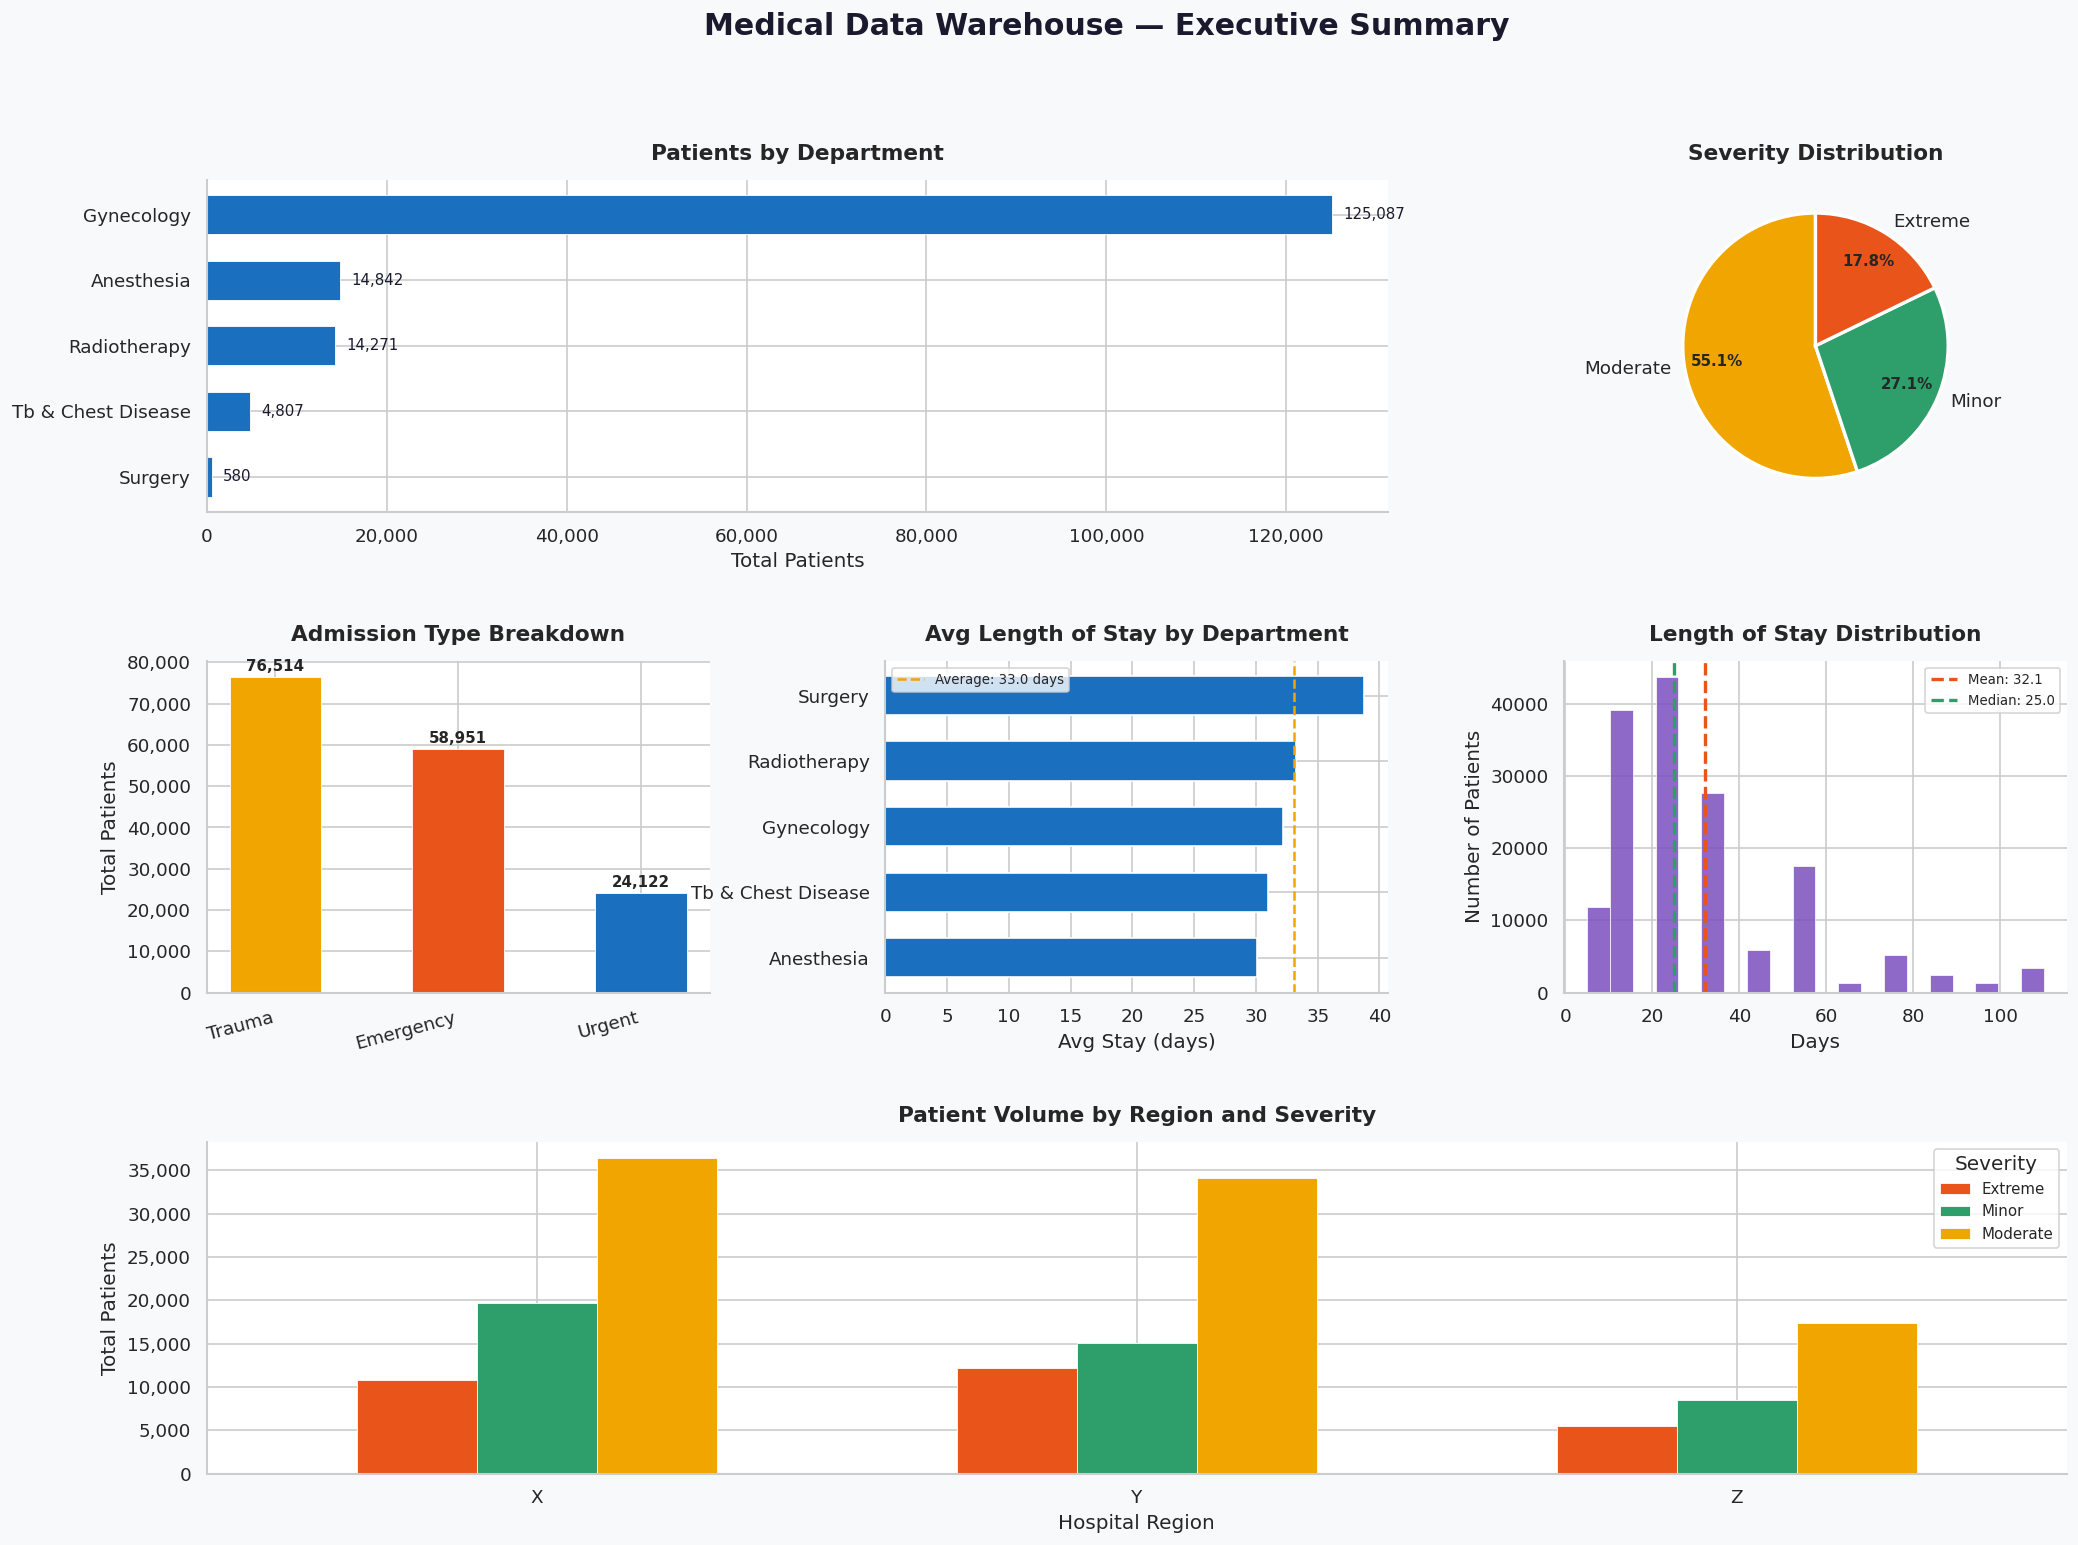

Executive summary saved!


In [ ]:
# ─────────────────────────────────────────────
# CELL — Page 1: Executive Summary Dashboard
# 6 charts showing overall hospital overview
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    'Medical Data Warehouse — Executive Summary',
    fontsize=18, fontweight='bold',
    color='#1A1A2E', y=0.98
)
fig.patch.set_facecolor('#F8F9FA')

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

# ── Color palettes ──────────────────────────
severity_colors = {
    'Extreme':  '#E8541A',
    'Moderate': '#F0A500',
    'Minor':    '#2E9E6B'
}
admission_colors = {
    'Emergency': '#E8541A',
    'Trauma':    '#F0A500',
    'Urgent':    '#1A6FBF'
}

# ── Chart 1 — Patients by Department ────────
ax1 = fig.add_subplot(gs[0, :2])
dept_counts = df_pd.groupby('Department')[
    'case_id'
].count().sort_values(ascending=True)

bars = ax1.barh(
    dept_counts.index,
    dept_counts.values,
    color='#1A6FBF',
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)

# Add value labels on bars
for bar, val in zip(bars, dept_counts.values):
    ax1.text(
        val + dept_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center', ha='left',
        fontsize=9, color='#1A1A2E'
    )

ax1.set_title('Patients by Department')
ax1.set_xlabel('Total Patients')
ax1.set_ylabel('')
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# ── Chart 2 — Severity Pie ───────────────────
ax2 = fig.add_subplot(gs[0, 2])
sev_counts = df_pd['Severity_of_Illness'].value_counts()
wedges, texts, autotexts = ax2.pie(
    sev_counts.values,
    labels=sev_counts.index,
    colors=[severity_colors.get(s, '#888')
            for s in sev_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')
ax2.set_title('Severity Distribution')

# ── Chart 3 — Admission Type Bar ─────────────
ax3 = fig.add_subplot(gs[1, 0])
adm_counts = df_pd['Type_of_Admission'].value_counts()
bars3 = ax3.bar(
    adm_counts.index,
    adm_counts.values,
    color=[admission_colors.get(a, '#888')
           for a in adm_counts.index],
    edgecolor='white',
    linewidth=0.5,
    width=0.5
)
for bar, val in zip(bars3, adm_counts.values):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + adm_counts.max() * 0.01,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax3.set_title('Admission Type Breakdown')
ax3.set_ylabel('Total Patients')
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax3.set_xticklabels(
    adm_counts.index, rotation=15, ha='right'
)

# ── Chart 4 — Avg Stay by Department ─────────
ax4 = fig.add_subplot(gs[1, 1])
avg_stay = df_pd.groupby('Department')[
    'Stay_Numeric'
].mean().sort_values(ascending=True)

colors_stay = [
    '#E8541A' if v > avg_stay.mean() * 1.2
    else '#1A6FBF'
    for v in avg_stay.values
]
bars4 = ax4.barh(
    avg_stay.index,
    avg_stay.values,
    color=colors_stay,
    edgecolor='white',
    height=0.6
)
ax4.axvline(
    avg_stay.mean(),
    color='#F0A500',
    linestyle='--',
    linewidth=1.5,
    label=f'Average: {avg_stay.mean():.1f} days'
)
ax4.set_title('Avg Length of Stay by Department')
ax4.set_xlabel('Avg Stay (days)')
ax4.legend(fontsize=8)

# ── Chart 5 — Stay Distribution Histogram ────
ax5 = fig.add_subplot(gs[1, 2])
stay_data = df_pd['Stay_Numeric'].dropna()
ax5.hist(
    stay_data,
    bins=20,
    color='#7B4FBF',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)
ax5.axvline(
    stay_data.mean(),
    color='#E8541A',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {stay_data.mean():.1f}'
)
ax5.axvline(
    stay_data.median(),
    color='#2E9E6B',
    linestyle='--',
    linewidth=2,
    label=f'Median: {stay_data.median():.1f}'
)
ax5.set_title('Length of Stay Distribution')
ax5.set_xlabel('Days')
ax5.set_ylabel('Number of Patients')
ax5.legend(fontsize=8)

# ── Chart 6 — Region Comparison ──────────────
ax6 = fig.add_subplot(gs[2, :])
region_data = df_pd.groupby(
    ['Hospital_region_code', 'Severity_of_Illness']
)['case_id'].count().unstack(fill_value=0)

region_data.plot(
    kind='bar',
    ax=ax6,
    color=[severity_colors.get(c, '#888')
           for c in region_data.columns],
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)
ax6.set_title(
    'Patient Volume by Region and Severity'
)
ax6.set_xlabel('Hospital Region')
ax6.set_ylabel('Total Patients')
ax6.legend(
    title='Severity',
    loc='upper right',
    fontsize=9
)
ax6.set_xticklabels(
    region_data.index,
    rotation=0
)
ax6.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.savefig(
    '/tmp/executive_summary.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#F8F9FA'
)
plt.show()
print("Executive summary saved!")

StatementMeta(smallsparkpool, 7, 26, Finished, Available, Finished, False)

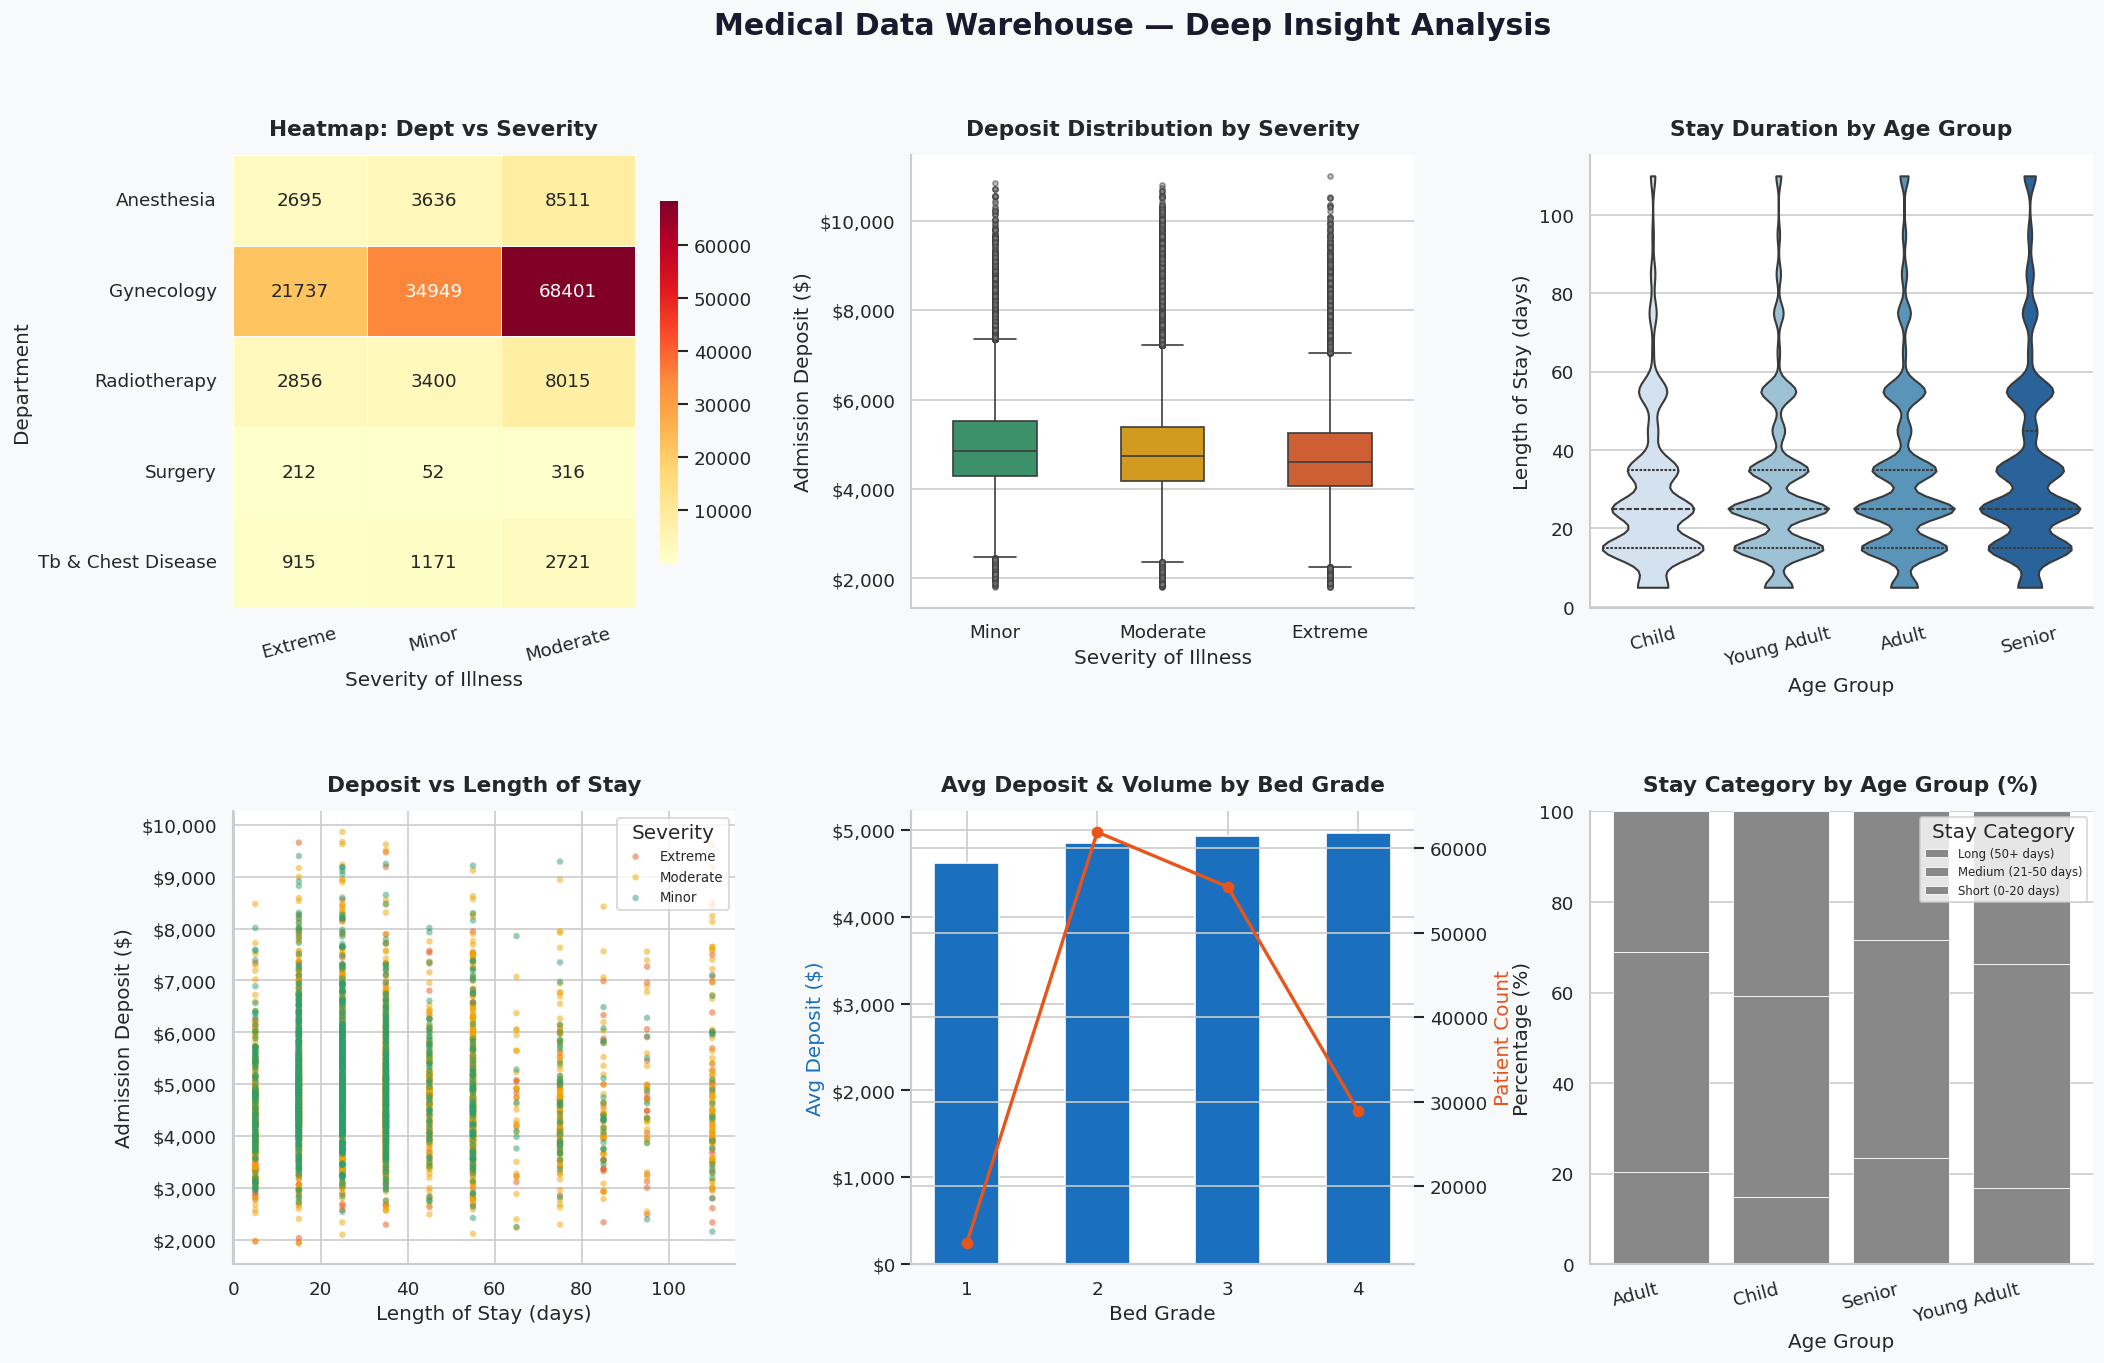

Deep insights saved!


In [ ]:
# ─────────────────────────────────────────────
# CELL — Page 2: Deep Insight Analysis
# Advanced statistical charts
# ─────────────────────────────────────────────

fig2, axes = plt.subplots(2, 3, figsize=(20, 12))
fig2.suptitle(
    'Medical Data Warehouse — Deep Insight Analysis',
    fontsize=18, fontweight='bold',
    color='#1A1A2E', y=0.98
)
fig2.patch.set_facecolor('#F8F9FA')
plt.subplots_adjust(
    hspace=0.45, wspace=0.35
)

# ── Chart 1 — Heatmap: Dept vs Severity ──────
ax = axes[0, 0]
heatmap_data = df_pd.groupby(
    ['Department', 'Severity_of_Illness']
)['case_id'].count().unstack(fill_value=0)

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='d',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Heatmap: Dept vs Severity')
ax.set_xlabel('Severity of Illness')
ax.set_ylabel('Department')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

# ── Chart 2 — Box Plot: Deposit by Severity ──
ax2 = axes[0, 1]
severity_order = ['Minor', 'Moderate', 'Extreme']
sns.boxplot(
    data=df_pd,
    x='Severity_of_Illness',
    y='Admission_Deposit',
    order=severity_order,
    palette=severity_colors,
    ax=ax2,
    width=0.5,
    flierprops={'marker':'o',
                'markerfacecolor':'grey',
                'markersize':3,
                'alpha':0.5}
)
ax2.set_title('Deposit Distribution by Severity')
ax2.set_xlabel('Severity of Illness')
ax2.set_ylabel('Admission Deposit ($)')
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x):,}')
)

# ── Chart 3 — Violin: Stay by Age Group ──────
ax3 = axes[0, 2]
age_order = [
    'Child', 'Young Adult', 'Adult', 'Senior'
]
sns.violinplot(
    data=df_pd[df_pd['Age_Group'].isin(age_order)],
    x='Age_Group',
    y='Stay_Numeric',
    order=age_order,
    palette='Blues',
    ax=ax3,
    inner='quartile',
    cut=0
)
ax3.set_title('Stay Duration by Age Group')
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Length of Stay (days)')
ax3.tick_params(axis='x', rotation=15)

# ── Chart 4 — Scatter: Deposit vs Stay ───────
ax4 = axes[1, 0]
# Use __builtins__ to access Python's original min()
sample_size = min(5000, len(df_pd)) \
    if not hasattr(min, '__module__') \
    else (5000 if len(df_pd) > 5000 else len(df_pd))

sample = df_pd.sample(
    n=sample_size, random_state=42
)
for severity, color in severity_colors.items():
    mask = sample['Severity_of_Illness'] == severity
    ax4.scatter(
        sample.loc[mask, 'Stay_Numeric'],
        sample.loc[mask, 'Admission_Deposit'],
        c=color, label=severity,
        alpha=0.5, s=15, edgecolors='none'
    )
ax4.set_title('Deposit vs Length of Stay')
ax4.set_xlabel('Length of Stay (days)')
ax4.set_ylabel('Admission Deposit ($)')
ax4.legend(title='Severity', fontsize=8)
ax4.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x):,}')
)

# ── Chart 5 — Bar: Avg Deposit by Bed Grade ──
ax5 = axes[1, 1]
bed_data = df_pd.groupby('Bed_Grade').agg(
    avg_deposit=('Admission_Deposit', 'mean'),
    patient_count=('case_id', 'count')
).reset_index().dropna()

bars5 = ax5.bar(
    bed_data['Bed_Grade'].astype(str),
    bed_data['avg_deposit'],
    color='#1A6FBF',
    edgecolor='white',
    width=0.5
)
ax5_twin = ax5.twinx()
ax5_twin.plot(
    bed_data['Bed_Grade'].astype(str),
    bed_data['patient_count'],
    color='#E8541A',
    marker='o',
    linewidth=2,
    markersize=6,
    label='Patient Count'
)
ax5.set_title('Avg Deposit & Volume by Bed Grade')
ax5.set_xlabel('Bed Grade')
ax5.set_ylabel('Avg Deposit ($)', color='#1A6FBF')
ax5_twin.set_ylabel(
    'Patient Count', color='#E8541A'
)
ax5.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x):,}')
)

# ── Chart 6 — Stacked Bar: Age vs Stay Cat ───
ax6 = axes[1, 2]
age_stay = df_pd.groupby(
    ['Age_Group', 'Stay_Category']
)['case_id'].count().unstack(fill_value=0)

stay_colors = {
    'Short stay (0-20 days)':   '#2E9E6B',
    'Medium stay (21-50 days)': '#F0A500',
    'Long stay (50+ days)':     '#E8541A'
}

age_stay_pct = age_stay.div(
    age_stay.sum(axis=1), axis=0
) * 100

bottom = np.zeros(len(age_stay_pct))
for col in age_stay_pct.columns:
    ax6.bar(
        range(len(age_stay_pct)),
        age_stay_pct[col],
        bottom=bottom,
        label=col,
        color=stay_colors.get(col, '#888'),
        edgecolor='white',
        linewidth=0.5
    )
    bottom += age_stay_pct[col].values

ax6.set_xticks(range(len(age_stay_pct)))
ax6.set_xticklabels(
    age_stay_pct.index, rotation=15, ha='right'
)
ax6.set_title('Stay Category by Age Group (%)')
ax6.set_xlabel('Age Group')
ax6.set_ylabel('Percentage (%)')
ax6.legend(
    title='Stay Category',
    fontsize=7,
    loc='upper right'
)
ax6.set_ylim(0, 100)

plt.savefig(
    '/tmp/deep_insights.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#F8F9FA'
)
plt.show()
print("Deep insights saved!")

In [ ]:
# ─────────────────────────────────────────────
# CELL — Print clean summary statistics
# Great to screenshot for portfolio
# ─────────────────────────────────────────────

print("=" * 55)
print("MEDICAL DATA WAREHOUSE — SUMMARY STATISTICS")
print("=" * 55)

# Overall stats
print(f"\nTotal records:        {len(df_pd):,}")
print(f"Unique patients:      {df_pd['patientid'].nunique():,}")
print(f"Unique hospitals:     {df_pd['Hospital_code'].nunique():,}")
print(f"Departments:          {df_pd['Department'].nunique():,}")
print(f"Regions:              {df_pd['Hospital_region_code'].nunique():,}")

# Numeric stats
print(f"\nAvg stay (days):      {df_pd['Stay_Numeric'].mean():.1f}")
print(f"Median stay (days):   {df_pd['Stay_Numeric'].median():.1f}")
print(f"Max stay (days):      {df_pd['Stay_Numeric'].max():.0f}")
print(f"Avg deposit ($):      ${df_pd['Admission_Deposit'].mean():,.2f}")
print(f"Total deposit ($):    ${df_pd['Admission_Deposit'].sum():,.0f}")

# Severity breakdown
print(f"\nSeverity breakdown:")
for sev, count in df_pd['Severity_of_Illness'] \
        .value_counts().items():
    pct = count / len(df_pd) * 100
    print(f"  {sev:<12} {count:>8,} ({pct:.1f}%)")

# Admission type breakdown
print(f"\nAdmission types:")
for adm, count in df_pd['Type_of_Admission'] \
        .value_counts().items():
    pct = count / len(df_pd) * 100
    print(f"  {adm:<12} {count:>8,} ({pct:.1f}%)")

# Top 3 departments
print(f"\nTop 3 departments by volume:")
top3 = df_pd.groupby('Department')['case_id'] \
            .count().sort_values(ascending=False).head(3)
for dept, count in top3.items():
    pct = count / len(df_pd) * 100
    print(f"  {dept:<20} {count:>8,} ({pct:.1f}%)")

print("\n" + "=" * 55)

StatementMeta(smallsparkpool, 7, 27, Finished, Available, Finished, False)

MEDICAL DATA WAREHOUSE — SUMMARY STATISTICS

Total records:        159,587
Unique patients:      74,155
Unique hospitals:     32
Departments:          5
Regions:              3

Avg stay (days):      32.1
Median stay (days):   25.0
Max stay (days):      110
Avg deposit ($):      $4,880.79
Total deposit ($):    $778,909,850

Severity breakdown:
  Moderate       87,964 (55.1%)
  Minor          43,208 (27.1%)
  Extreme        28,415 (17.8%)

Admission types:
  Trauma         76,514 (47.9%)
  Emergency      58,951 (36.9%)
  Urgent         24,122 (15.1%)

Top 3 departments by volume:
  Gynecology            125,087 (78.4%)
  Anesthesia             14,842 (9.3%)
  Radiotherapy           14,271 (8.9%)

